# Tema 1 CC - EDA, regresie si clasificare

Notebook-ul este organizat ca un raport tehnic, in ordinea in care am lucrat:

1. **Partea A - EDA general**: incarcare date, tipuri de atribute, valori lipsa, statistici, distributii, outlieri, redundanta si privire asupra tintelor `salary` si `vacation`.
2. **Partea B - regresie**: analiza pentru `salary`, preprocesare, baseline liniar, regularizare, comparatie de metrici, analiza erorilor si jurnalul etapelor de perfectionare pentru Kaggle.
3. **Partea C - clasificare**: analiza pentru `vacation`, baseline cu arbore de decizie, variatie de hiperparametri, modele mai puternice si o versiune V1 data-centric pentru clasificare.

Reperele de punctaj urmarite in notebook:
- EDA: tipuri de atribute, plaje de valori, valori lipsa, outlieri, redundanta, tabele si grafice interpretate;
- clasificare: baseline cu `DecisionTreeClassifier`, cel putin o variatie de hiperparametru, encodare pentru categorice, tabel de metrici si matrice de confuzie;
- regresie: baseline cu `LinearRegression`, regularizare variata, metrici train/test si analiza regularizarii;
- evaluare: tabele comparative, comentarii despre modelele alese si verificarea formatului `id,prediction` pentru fisierele finale.


In [1]:
# Daca mediul nu are dependintele instalate:
# %pip install numpy pandas scikit-learn matplotlib seaborn

import os
import warnings
from pathlib import Path

MPL_CACHE_DIR = Path(".matplotlib_cache")
MPL_CACHE_DIR.mkdir(exist_ok=True)
XDG_CACHE_DIR = Path(".cache")
XDG_CACHE_DIR.mkdir(exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(MPL_CACHE_DIR.resolve()))
os.environ.setdefault("XDG_CACHE_HOME", str(XDG_CACHE_DIR.resolve()))

import numpy as np
import pandas as pd

RANDOM_STATE = 42
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)
warnings.filterwarnings("ignore", message="X does not have valid feature names.*")


# PARTEA A - GENERAL

## A1. Incarcare date si rolul fiecarui fisier

Avem deja fisiere separate, deci **nu impartim manual train-ul in train/validation**.

- `CC_education_economy_train.csv` = antrenare;
- `CC_education_economy_test.csv` = validare 
- `CC_private_test.csv` = test privat pentru Kaggle/submission, fara tinte => testare


In [2]:
DATA_DIR = Path(".")
TRAIN_PATH = DATA_DIR / "CC_education_economy_train.csv"
TEST_PATH = DATA_DIR / "CC_education_economy_test.csv"
PRIVATE_TEST_PATH = DATA_DIR / "CC_private_test.csv"

REGRESSION_TARGET = "salary"
CLASSIFICATION_TARGET = "vacation"

train_raw = pd.read_csv(TRAIN_PATH)
test_raw = pd.read_csv(TEST_PATH)
private_test_raw = pd.read_csv(PRIVATE_TEST_PATH) if PRIVATE_TEST_PATH.exists() else None

print("train:", train_raw.shape)
print("test local:", test_raw.shape)
if private_test_raw is not None:
    print("private test:", private_test_raw.shape)

display(train_raw.head())


train: (64000, 14)
test local: (16000, 14)
private test: (16000, 13)


,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary,total_days_worked,aggregated_score,skill_bracket,vacation
0,Backend Developer,19,High School,12,Media,Large,USA,Yes,0,203997,4560,-0.723308,mid,Small
1,Backend Developer,4,High School,13,Telecom,Small,Germany,NaN,5,116239,960,-0.481551,high,No Vacation
2,Backend Developer,8,High School,16,Retail,Enterprise,Remote,No,4,145802,1920,-1.533057,high,No Vacation
3,Backend Developer,12,High School,9,Telecom,Enterprise,USA,Hybrid,2,190299,2880,0.527458,mid,Small
4,Backend Developer,14,High School,6,Telecom,Large,UK,Hybrid,4,152679,3360,-0.186280,low,No Vacation


## A2. Tipuri de atribute si valori lipsa

Aici este EDA general: Intelegem coloanele, tipurile si problemele evidente din date. Aceasta sectiune este utila si pentru regresie, si pentru clasificare.


In [3]:
FEATURE_COLS = [c for c in train_raw.columns if c not in [REGRESSION_TARGET, CLASSIFICATION_TARGET]]
NUMERIC_FEATURES_EDA = train_raw[FEATURE_COLS].select_dtypes(include=[np.number]).columns.tolist()
CATEGORICAL_FEATURES_EDA = [c for c in FEATURE_COLS if c not in NUMERIC_FEATURES_EDA]

feature_types = pd.DataFrame([
    ("job_title", "categorial nominal", "functie"),
    ("experience_years", "numeric", "experienta"),
    ("education_level", "ordinal/categorial", "nivel educational"),
    ("skills_count", "numeric discret", "numar skill-uri"),
    ("industry", "categorial nominal", "industrie"),
    ("company_size", "ordinal/categorial", "dimensiune companie"),
    ("location", "categorial nominal", "locatie"),
    ("remote_work", "categorial nominal", "are valori lipsa"),
    ("certifications", "numeric discret", "numar certificari"),
    ("total_days_worked", "numeric", "posibil redundant cu experience_years"),
    ("aggregated_score", "numeric continuu", "scor agregat"),
    ("skill_bracket", "ordinal/categorial", "nivel skill-uri"),
    ("salary", "tinta regresie", "nu este feature"),
    ("vacation", "tinta clasificare", "nu este feature"),
], columns=["coloana", "tip", "observatie"])

display(feature_types)

missing_report = pd.DataFrame({
    "missing_count": train_raw.isna().sum(),
    "missing_percent": (train_raw.isna().mean() * 100).round(2),
}).query("missing_count > 0").sort_values("missing_count", ascending=False)

print("Valori lipsa:")
display(missing_report)


,coloana,tip,observatie
0,job_title,categorial nominal,functie
1,experience_years,numeric,experienta
2,education_level,ordinal/categorial,nivel educational
3,skills_count,numeric discret,numar skill-uri
4,industry,categorial nominal,industrie
5,company_size,ordinal/categorial,dimensiune companie
6,location,categorial nominal,locatie
7,remote_work,categorial nominal,are valori lipsa
8,certifications,numeric discret,numar certificari
9,total_days_worked,numeric,posibil redundant cu experience_years


Valori lipsa:


,missing_count,missing_percent
remote_work,19153,29.93


## A3. Statistici si distributii generale pentru features

Statistici pentru numerice si un tabel pentru categorice/ordinale. Graficele de aici sunt generale: ne uitam la plaja valorilor si distributii.


In [4]:
# Statistici numerice: count, mean, std, min, percentile si max.
numeric_stats = train_raw[NUMERIC_FEATURES_EDA].describe().T.rename(columns={"50%": "median"})
numeric_stats = numeric_stats[["count", "mean", "std", "min", "25%", "median", "75%", "max"]]
display(numeric_stats.round(2))

# Tabel pentru categorice/ordinale: numar non-lipsa si numar valori unice.
cat_stats = pd.DataFrame({
    "non_missing_count": train_raw[CATEGORICAL_FEATURES_EDA].notna().sum(),
    "missing_count": train_raw[CATEGORICAL_FEATURES_EDA].isna().sum(),
    "unique_values_including_missing": train_raw[CATEGORICAL_FEATURES_EDA].nunique(dropna=False),
})
display(cat_stats)


,count,mean,std,min,25%,median,75%,max
experience_years,64000.0,9.97,6.05,0.0,5.00,10.0,15.00,20.00
skills_count,64000.0,11.60,10.74,1.0,5.00,10.0,15.00,69.00
certifications,64000.0,2.51,1.71,0.0,1.00,3.0,4.00,5.00
total_days_worked,64000.0,2393.51,1452.04,-1.0,1200.00,2400.0,3600.00,4800.00
aggregated_score,64000.0,0.00,1.00,-4.8,-0.67,0.0,0.68,4.22


,non_missing_count,missing_count,unique_values_including_missing
job_title,64000,0,12
education_level,64000,0,5
industry,64000,0,10
company_size,64000,0,5
location,64000,0,10
remote_work,44847,19153,4
skill_bracket,64000,0,3


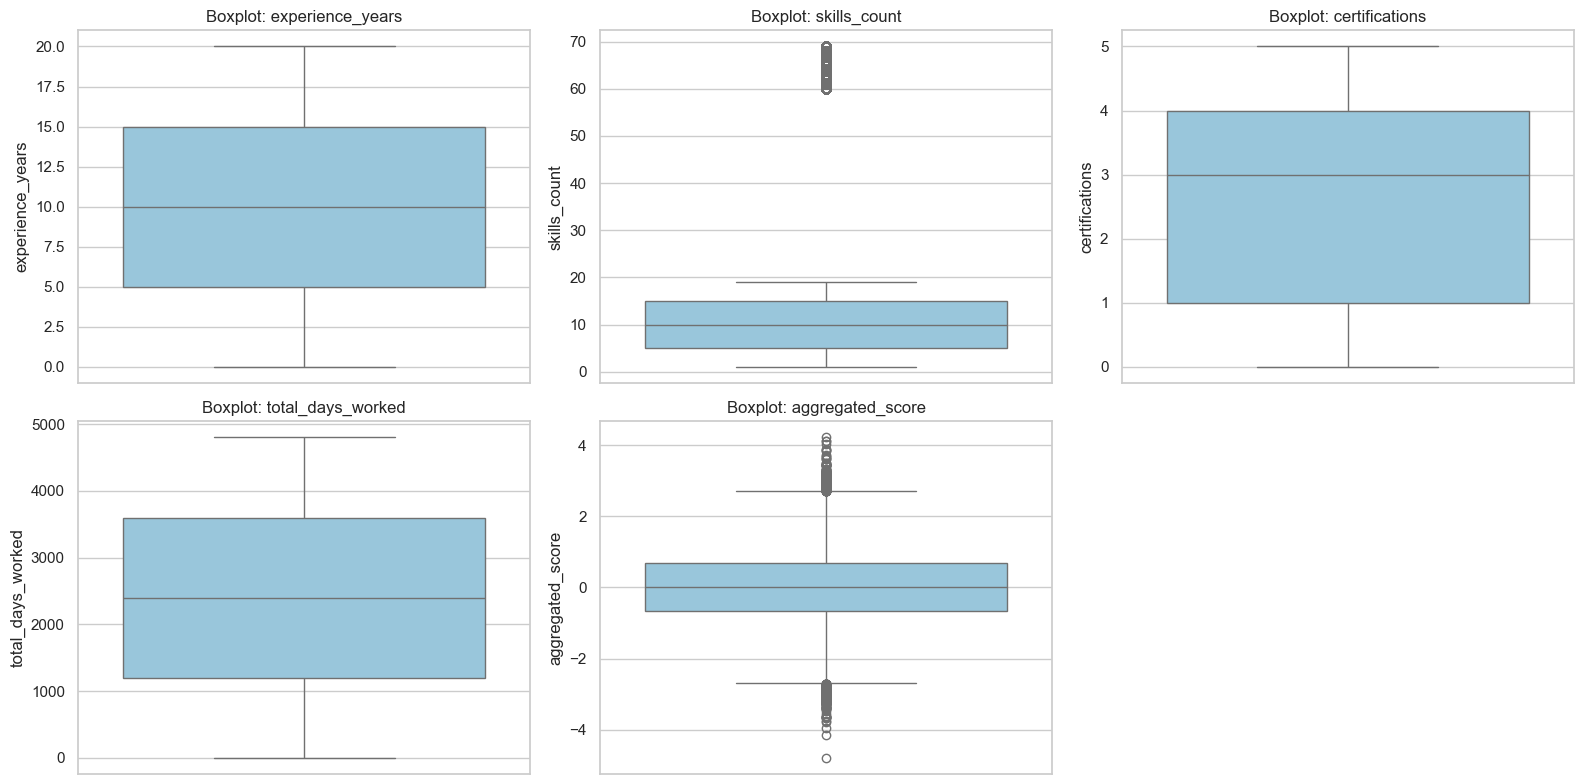

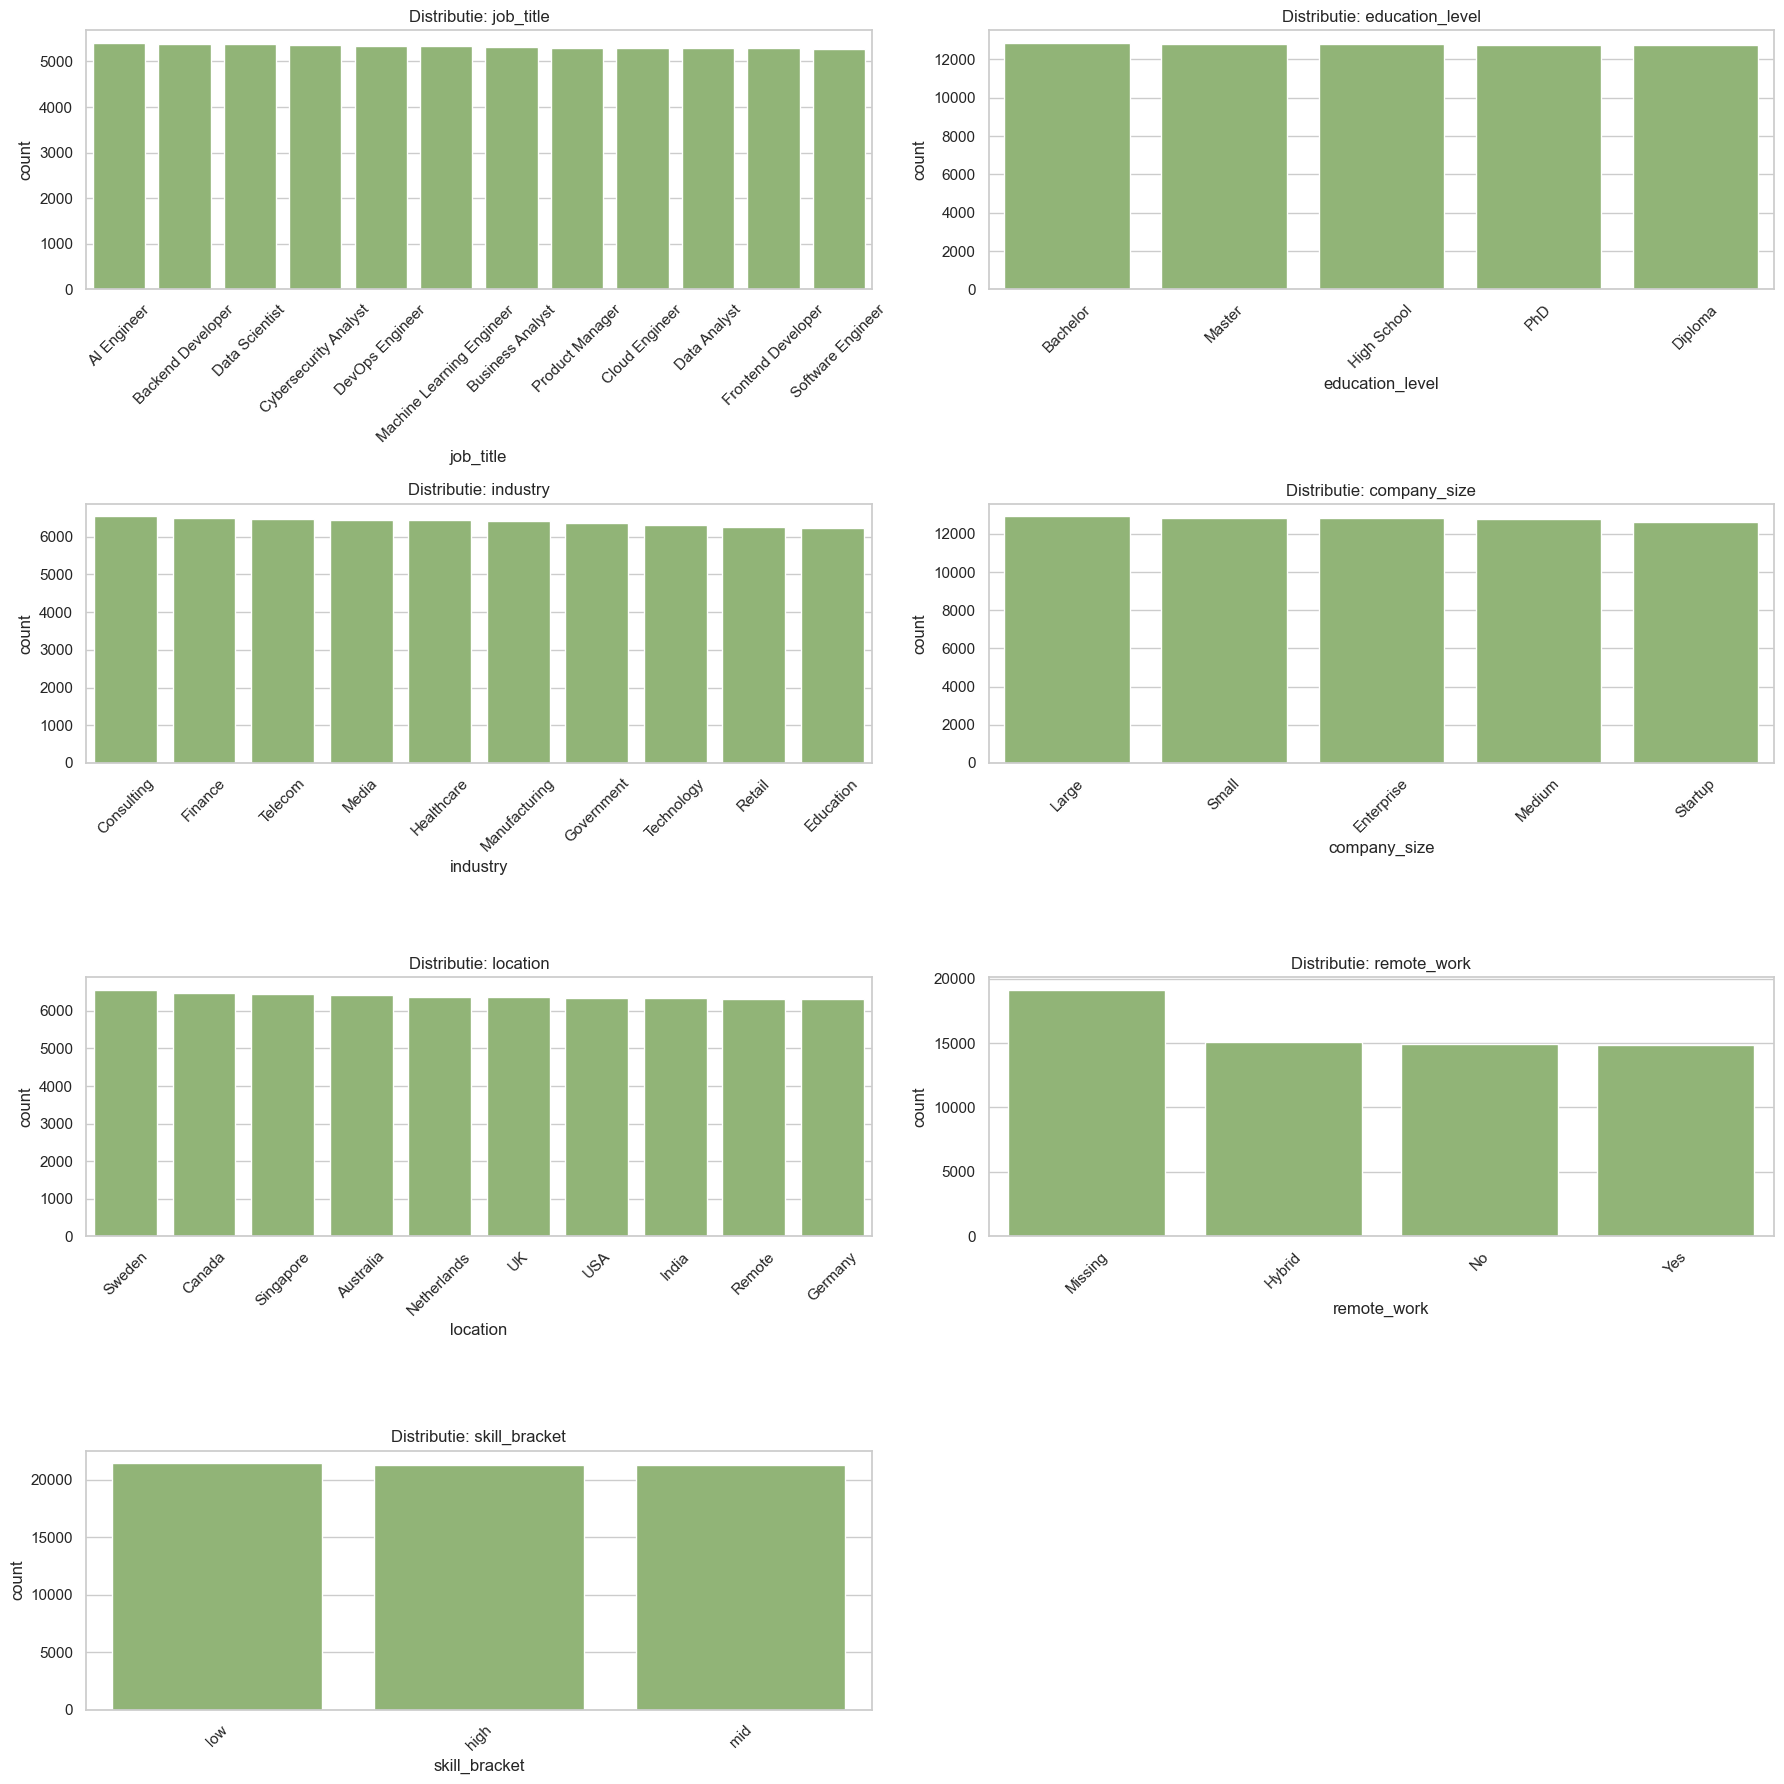

In [5]:
# Vizualizari generale: boxplot pentru numerice si countplot pentru categorice.
# Le grupam ca sa pastram EDA-ul compact si lizibil.
try:
    import matplotlib.pyplot as plt
    import seaborn as sns
    PLOTS_AVAILABLE = True
except ImportError:
    PLOTS_AVAILABLE = False
    print("Pentru grafice ruleaza: %pip install matplotlib seaborn")

if PLOTS_AVAILABLE:
    sns.set_theme(style="whitegrid")

    fig, axes = plt.subplots(2, 3, figsize=(16, 8))
    numeric_axes = axes.ravel()
    for ax, col in zip(numeric_axes, NUMERIC_FEATURES_EDA):
        sns.boxplot(y=train_raw[col], ax=ax, color="#8ecae6")
        ax.set_title(f"Boxplot: {col}")
    for ax in numeric_axes[len(NUMERIC_FEATURES_EDA):]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()

    fig, axes = plt.subplots(4, 2, figsize=(18, 18))
    axes = axes.ravel()
    for ax, col in zip(axes, CATEGORICAL_FEATURES_EDA):
        values = train_raw[col].fillna("Missing").astype(str)
        sns.countplot(x=values, order=values.value_counts().index, ax=ax, color="#90be6d")
        ax.set_title(f"Distributie: {col}")
        ax.tick_params(axis="x", rotation=45)
    for ax in axes[len(CATEGORICAL_FEATURES_EDA):]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()


## A4. Outlieri si redundanta intre features

Aceasta este tot parte generala: identificam valori extreme si features redundante inainte sa alegem modele. Tratamentul exact il aplicam mai jos, in partea de preprocesare.


In [6]:
def iqr_bounds(series: pd.Series, q1=0.25, q3=0.75, multiplier=1.5):
    q_low = series.quantile(q1)
    q_high = series.quantile(q3)
    iqr = q_high - q_low
    return q_low - multiplier * iqr, q_high + multiplier * iqr

outlier_rows = []
for col in NUMERIC_FEATURES_EDA:
    lower, upper = iqr_bounds(train_raw[col])
    mask = (train_raw[col] < lower) | (train_raw[col] > upper)
    outlier_rows.append({
        "feature": col,
        "iqr_lower": lower,
        "iqr_upper": upper,
        "outlier_count": int(mask.sum()),
        "outlier_percent": round(mask.mean() * 100, 2),
    })

outlier_report = pd.DataFrame(outlier_rows).sort_values("outlier_count", ascending=False)
display(outlier_report)

feature_corr = train_raw[NUMERIC_FEATURES_EDA].corr(numeric_only=True)
display(feature_corr.round(3))

high_corr_pairs = []
for i, c1 in enumerate(NUMERIC_FEATURES_EDA):
    for c2 in NUMERIC_FEATURES_EDA[i + 1:]:
        corr_value = feature_corr.loc[c1, c2]
        if abs(corr_value) >= 0.9:
            high_corr_pairs.append((c1, c2, corr_value))

print("Perechi numerice foarte corelate:")
display(pd.DataFrame(high_corr_pairs, columns=["feature_1", "feature_2", "correlation"]).round(3))


,feature,iqr_lower,iqr_upper,outlier_count,outlier_percent
1,skills_count,-10.000000,30.000000,1909,2.98
4,aggregated_score,-2.701801,2.706318,437,0.68
0,experience_years,-10.000000,30.000000,0,0.00
2,certifications,-3.500000,8.500000,0,0.00
3,total_days_worked,-2400.000000,7200.000000,0,0.00


,experience_years,skills_count,certifications,total_days_worked,aggregated_score
experience_years,1.000,0.003,0.002,1.000,-0.001
skills_count,0.003,1.000,0.002,0.003,0.006
certifications,0.002,0.002,1.000,0.002,-0.000
total_days_worked,1.000,0.003,0.002,1.000,-0.001
aggregated_score,-0.001,0.006,-0.000,-0.001,1.000


Perechi numerice foarte corelate:


,feature_1,feature_2,correlation
0,experience_years,total_days_worked,1.0


## A5. Privire scurta asupra tintelor

Aici doar intelegem cele doua tinte ale temei:
- `vacation` este tinta de clasificare si necesita analiza echilibrului de clase;
- `salary` este tinta de regresie si necesita analiza distributiei valorilor.

Aceasta este doar o privire generala; modelele propriu-zise sunt antrenate separat in Partea B pentru regresie si in Partea C pentru clasificare.


,count,percent
vacation,,
No Vacation,34686,54.20
Small,12877,20.12
Medium,8527,13.32
Large,7910,12.36


,salary
count,64000.00
mean,145683.57
std,37384.76
min,31867.00
25%,119209.75
50%,143299.00
75%,169582.25
max,333046.00


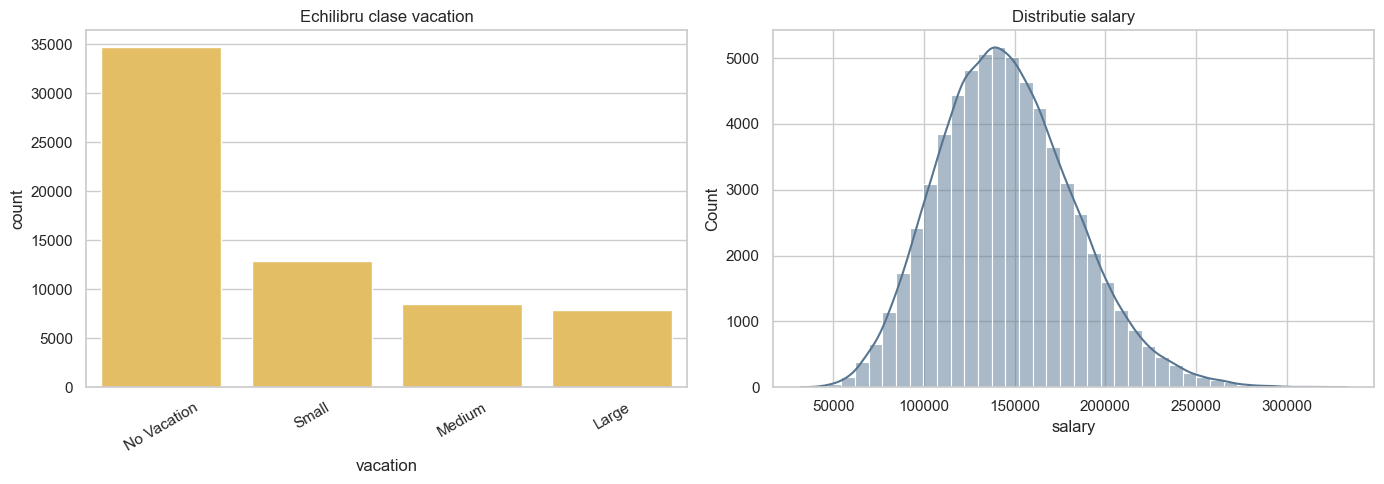

In [7]:
class_balance = pd.concat([
    train_raw[CLASSIFICATION_TARGET].value_counts().rename("count"),
    (train_raw[CLASSIFICATION_TARGET].value_counts(normalize=True) * 100).round(2).rename("percent"),
], axis=1)
display(class_balance)

display(train_raw[REGRESSION_TARGET].describe().to_frame("salary").round(2))

if PLOTS_AVAILABLE:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.countplot(x=train_raw[CLASSIFICATION_TARGET], order=train_raw[CLASSIFICATION_TARGET].value_counts().index, ax=axes[0], color="#f9c74f")
    axes[0].set_title("Echilibru clase vacation")
    axes[0].tick_params(axis="x", rotation=30)

    sns.histplot(train_raw[REGRESSION_TARGET], bins=40, kde=True, ax=axes[1], color="#577590")
    axes[1].set_title("Distributie salary")
    plt.tight_layout()
    plt.show()


# PARTEA B - REGRESIE

De aici incepe lucrul strict pentru regresie. Tinta este `salary`.


## B1. EDA specific pentru regresie

Pentru regresie urmaresc legatura dintre `salary` si restul atributelor:

- corelatii numerice cu `salary`;
- diferente de salariu pe categorii;
- cateva scatter/box plots relevante, pastrate intr-un numar mic ca sa ramana usor de citit.


In [8]:
NUMERIC_COLS_WITH_TARGET = NUMERIC_FEATURES_EDA + [REGRESSION_TARGET]
regression_corr = train_raw[NUMERIC_COLS_WITH_TARGET].corr(numeric_only=True)

print("Corelatie numerice cu salary:")
display(regression_corr[REGRESSION_TARGET].sort_values(ascending=False).round(3))

for col in ["job_title", "education_level", "company_size", "location", "remote_work", "skill_bracket"]:
    grouped = train_raw.groupby(col, dropna=False)[REGRESSION_TARGET].agg(["count", "mean", "median", "std"]).sort_values("mean", ascending=False).round(2)
    print(f"\nSalary by {col}")
    display(grouped)


Corelatie numerice cu salary:


salary               1.000
experience_years     0.437
total_days_worked    0.437
certifications       0.077
skills_count         0.065
aggregated_score    -0.004
Name: salary, dtype: float64


Salary by job_title


,count,mean,median,std
job_title,,,,
AI Engineer,5410,173162.56,171337.5,38102.99
Machine Learning Engineer,5337,163118.60,160990.0,36874.80
Product Manager,5302,157107.45,155277.5,35567.85
Cloud Engineer,5300,152619.18,150332.0,35386.68
DevOps Engineer,5344,150013.86,148571.0,34529.76
Cybersecurity Analyst,5356,147907.72,145822.5,34245.70
Data Scientist,5383,147289.90,145268.0,34156.61
Software Engineer,5272,141563.93,138737.5,33902.85
Backend Developer,5389,139574.41,137083.0,33080.63



Salary by education_level


...

,count,mean,median,std
location,,,,
USA,6352,181341.00,178628.0,37782.33
Canada,6469,167938.89,166020.0,35087.79
UK,6365,160347.37,158671.0,33426.84
Germany,6325,153640.37,151718.0,31782.86
Remote,6328,139429.03,137542.5,28919.00
Sweden,6570,139359.67,138062.0,28993.86
Singapore,6438,139058.85,137503.0,29014.11
Netherlands,6376,138904.57,136798.5,29313.18
Australia,6434,138865.53,137025.5,29264.78



Salary by remote_work


,count,mean,median,std
remote_work,,,,
Yes,14838,149609.81,147698.5,37476.23
NaN,19153,145131.00,142754.0,37411.27
Hybrid,15054,144482.91,141962.0,37218.57
No,14955,143704.32,141238.0,37148.23



Salary by skill_bracket


,count,mean,median,std
skill_bracket,,,,
high,21277,151338.83,149227.0,37797.32
mid,21253,145485.08,142931.0,37225.30
low,21470,140275.62,137846.0,36301.60


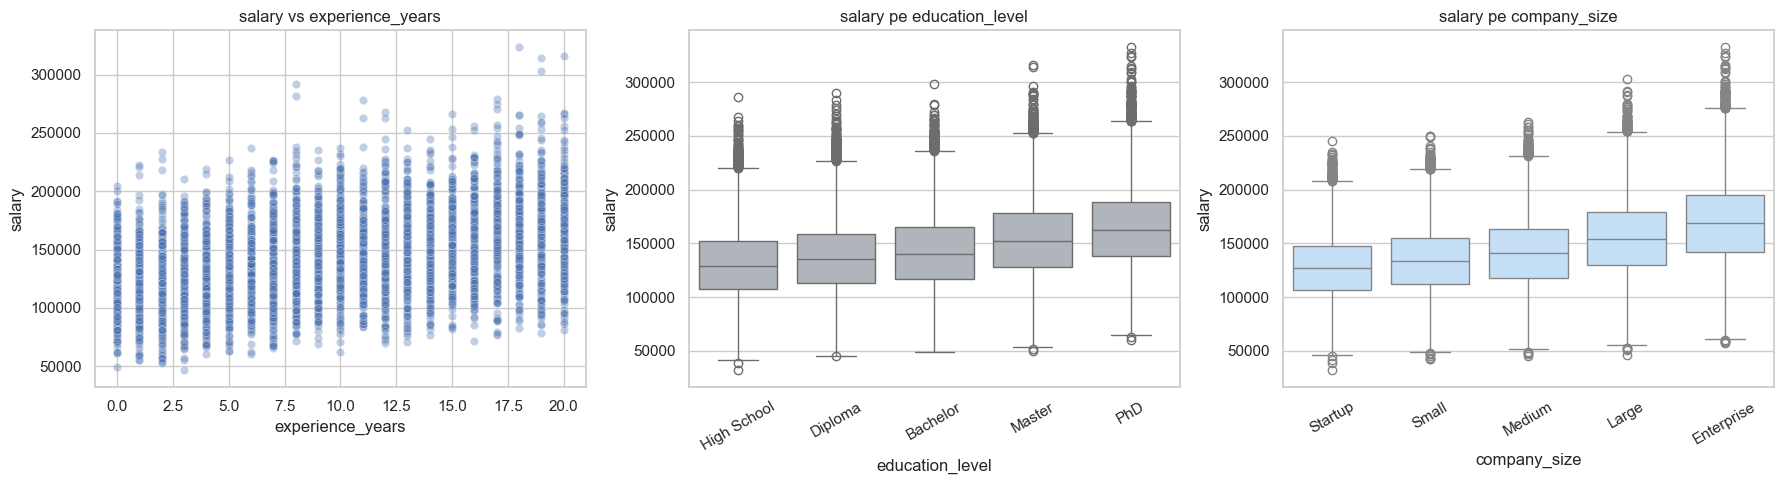

In [9]:
if PLOTS_AVAILABLE:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    sns.scatterplot(data=train_raw.sample(min(5000, len(train_raw)), random_state=RANDOM_STATE), x="experience_years", y=REGRESSION_TARGET, alpha=0.35, ax=axes[0])
    axes[0].set_title("salary vs experience_years")

    sns.boxplot(data=train_raw, x="education_level", y=REGRESSION_TARGET, order=["High School", "Diploma", "Bachelor", "Master", "PhD"], ax=axes[1], color="#adb5bd")
    axes[1].set_title("salary pe education_level")
    axes[1].tick_params(axis="x", rotation=30)

    sns.boxplot(data=train_raw, x="company_size", y=REGRESSION_TARGET, order=["Startup", "Small", "Medium", "Large", "Enterprise"], ax=axes[2], color="#bde0fe")
    axes[2].set_title("salary pe company_size")
    axes[2].tick_params(axis="x", rotation=30)

    plt.tight_layout()
    plt.show()


## B2. Preprocesare pentru regresie

Preprocesarea de aici este pentru modelele locale simple folosite ca baseline:

- elimin `salary`, pentru ca este tinta;
- elimin `vacation`, pentru ca apartine taskului de clasificare si ar produce leakage;
- elimin `total_days_worked`, fiind aproape identic cu `experience_years`;
- tratez outlierii din `aggregated_score` prin IQR clipping, cu limite calculate doar pe train;
- adaug cateva features simple derivate;
- folosesc imputare, OneHotEncoding si StandardScaler in pipeline-ul modelelor liniare.

Modelele grele din perfectionarea Kaggle folosesc o reteta separata, documentata in B4: target encoding, pseudo-labeling, seed ensembling si binning data-centric.


In [10]:
# Coloane excluse din regresie.
EXCLUDED_FROM_REGRESSION = [REGRESSION_TARGET, CLASSIFICATION_TARGET, "total_days_worked"]
BASE_FEATURES = [c for c in train_raw.columns if c not in EXCLUDED_FROM_REGRESSION]

print("Features folosite in regresie:")
print(BASE_FEATURES)
print("Features excluse:")
print(EXCLUDED_FROM_REGRESSION)

AGG_SCORE_LOWER, AGG_SCORE_UPPER = iqr_bounds(train_raw["aggregated_score"])
outlier_mask = (train_raw["aggregated_score"] < AGG_SCORE_LOWER) | (train_raw["aggregated_score"] > AGG_SCORE_UPPER)
print("aggregated_score IQR bounds:", AGG_SCORE_LOWER, AGG_SCORE_UPPER)
print("Numar outlieri aggregated_score in train:", int(outlier_mask.sum()))


Features folosite in regresie:
['job_title', 'experience_years', 'education_level', 'skills_count', 'industry', 'company_size', 'location', 'remote_work', 'certifications', 'aggregated_score', 'skill_bracket']
Features excluse:
['salary', 'vacation', 'total_days_worked']


aggregated_score IQR bounds: -2.7018013625585664 2.7063182160590395
Numar outlieri aggregated_score in train: 437


In [11]:
EDUCATION_ORDER = {"High School": 0, "Diploma": 1, "Bachelor": 2, "Master": 3, "PhD": 4}
COMPANY_SIZE_ORDER = {"Startup": 0, "Small": 1, "Medium": 2, "Large": 3, "Enterprise": 4}
SKILL_BRACKET_ORDER = {"low": 0, "mid": 1, "high": 2}

ORDINAL_DERIVED_COLS = ["education_level_ord", "company_size_ord", "skill_bracket_ord"]


def add_regression_base_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    # Tratam outlierii din aggregated_score prin clipping cu limite calculate pe train.
    # Pastram semnul original al scorului; nu mai adaugam abs/sq, ca sa nu pierdem directia negativ/pozitiv.
    if "aggregated_score" in out.columns:
        out["aggregated_score"] = out["aggregated_score"].clip(AGG_SCORE_LOWER, AGG_SCORE_UPPER)

    # Lipsa din remote_work poate fi informatie, deci pastram indicator separat.
    if "remote_work" in out.columns:
        out["remote_work_missing"] = out["remote_work"].isna().astype("int8")

    # Codari ordinale suplimentare; pastram si textul original pentru OneHotEncoding.
    if "education_level" in out.columns:
        out["education_level_ord"] = out["education_level"].map(EDUCATION_ORDER).astype(float)
    if "company_size" in out.columns:
        out["company_size_ord"] = out["company_size"].map(COMPANY_SIZE_ORDER).astype(float)
    if "skill_bracket" in out.columns:
        out["skill_bracket_ord"] = out["skill_bracket"].map(SKILL_BRACKET_ORDER).astype(float)

    # Interactiuni simple pentru experienta + competente.
    if {"experience_years", "skills_count"}.issubset(out.columns):
        years = out["experience_years"].replace(0, np.nan)
        out["skills_per_year"] = (out["skills_count"] / years).replace([np.inf, -np.inf], np.nan).fillna(out["skills_count"])
        out["experience_x_skills"] = out["experience_years"] * out["skills_count"]

    if {"experience_years", "certifications"}.issubset(out.columns):
        years = out["experience_years"].replace(0, np.nan)
        out["certifications_per_year"] = (out["certifications"] / years).replace([np.inf, -np.inf], np.nan).fillna(out["certifications"])

    return out


X_train_base = add_regression_base_features(train_raw[BASE_FEATURES])
y_train = train_raw[REGRESSION_TARGET]
X_test_base = add_regression_base_features(test_raw[BASE_FEATURES])
y_test = test_raw[REGRESSION_TARGET]

CAT_COLS = X_train_base.select_dtypes(include=["object", "category"]).columns.tolist()
NUM_COLS = [c for c in X_train_base.columns if c not in CAT_COLS]

# Modelele liniare folosesc OneHot pe coloanele ordinale originale, deci excludem variantele _ord ca sa evitam dublarea.
LINEAR_NUM_COLS = [c for c in NUM_COLS if c not in ORDINAL_DERIVED_COLS]
LINEAR_CAT_COLS = CAT_COLS

print("X_train:", X_train_base.shape, "X_test:", X_test_base.shape)
print("Linear numerice:", LINEAR_NUM_COLS)
print("Linear categorice:", LINEAR_CAT_COLS)


X_train: (64000, 18) X_test: (16000, 18)
Linear numerice: ['experience_years', 'skills_count', 'certifications', 'aggregated_score', 'remote_work_missing', 'skills_per_year', 'experience_x_skills', 'certifications_per_year']
Linear categorice: ['job_title', 'education_level', 'industry', 'company_size', 'location', 'remote_work', 'skill_bracket']


/var/folders/71/k6vnwdys64j39h1cb7d519yw0000gn/T/ipykernel_5712/3965918816.py:46: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  CAT_COLS = X_train_base.select_dtypes(include=["object", "category"]).columns.tolist()


# B3. Modele de regresie locale si metrici


In [12]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler


def make_one_hot_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=True)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=True)


def make_linear_preprocessor():
    """Pentru modele liniare: imputare + OneHot + StandardScaler."""
    numeric_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])
    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
        ("onehot", make_one_hot_encoder()),
    ])
    return ColumnTransformer([
        ("num", numeric_pipeline, LINEAR_NUM_COLS),
        ("cat", categorical_pipeline, LINEAR_CAT_COLS),
    ])


def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def regression_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "MSE": mean_squared_error(y_true, y_pred),
        "RMSE": rmse(y_true, y_pred),
        "R2": r2_score(y_true, y_pred),
    }


def evaluate_model(name, model, preprocessing_note, hyperparams_note):
    model.fit(X_train_base, y_train)
    train_pred = model.predict(X_train_base)
    test_pred = model.predict(X_test_base)

    train_metrics = regression_metrics(y_train, train_pred)
    test_metrics = regression_metrics(y_test, test_pred)

    row = {
        "model": name,
        "preprocessing": preprocessing_note,
        "hyperparams": hyperparams_note,
        "train_MSE": train_metrics["MSE"],
        "test_MSE": test_metrics["MSE"],
        "test_RMSE": test_metrics["RMSE"],
        "test_MAE": test_metrics["MAE"],
        "test_R2": test_metrics["R2"],
    }
    return row, test_pred, model



## B3. Baseline regresie si metrici

Primul reper pentru regresie este `LinearRegression`. Dupa el testez regularizarea cu `Ridge` si `Lasso`, apoi compar modelele prin:

- `MSE`, metrica principala pentru regresie in aceasta tema;
- `RMSE` si `MAE`, pentru interpretare in unitati apropiate de salariu;
- `R2`, ca masura a variatiei explicate.


In [13]:
# Baseline de regresie: LinearRegression.
linear_model = Pipeline([
    ("preprocess", make_linear_preprocessor()),
    ("model", LinearRegression()),
])

linear_metrics, linear_pred, fitted_linear_model = evaluate_model(
    name="LinearRegression_baseline",
    model=linear_model,
    preprocessing_note="imputare + OneHot + StandardScaler",
    hyperparams_note="fara regularizare",
)

display(pd.DataFrame([linear_metrics]))


,model,preprocessing,hyperparams,train_MSE,test_MSE,test_RMSE,test_MAE,test_R2
0,LinearRegression_baseline,imputare + OneHot + StandardScaler,fara regularizare,5.560506e+07,5.493644e+07,7411.912316,5731.122098,0.960231


## B3.1. Ridge - regularizare L2

Dupa baseline-ul liniar simplu, adaug regularizare L2 prin `Ridge`. Testez doua valori pentru `alpha`, deoarece acest hiperparametru controleaza cat de puternic sunt penalizati coeficientii. Scopul este sa vedem daca regularizarea reduce overfitting-ul fata de `LinearRegression`.


In [14]:

# Varianta cu regularizare Ridge: testam doua valori diferite pentru alpha.
# Am ales 1.0 si 10.0 ca valori comune de testat pentru Ridge.
ridge_1_model = Pipeline([
    ("preprocess", make_linear_preprocessor()),
    ("model", Ridge(alpha=1.0)),
])
ridge_10_model = Pipeline([
    ("preprocess", make_linear_preprocessor()),
    ("model", Ridge(alpha=10.0)),
])

ridge_1_metrics, ridge_1_pred, fitted_ridge_1_model = evaluate_model(
    name="Ridge_alpha_1",
    model=ridge_1_model,
    preprocessing_note="imputare + OneHot + StandardScaler",
    hyperparams_note="alpha=1.0",
)
ridge_10_metrics, ridge_10_pred, fitted_ridge_10_model = evaluate_model(
    name="Ridge_alpha_10",
    model=ridge_10_model,
    preprocessing_note="imputare + OneHot + StandardScaler",
    hyperparams_note="alpha=10.0",
)

all_results = [linear_metrics, ridge_1_metrics, ridge_10_metrics]
all_predictions = {
    "LinearRegression_baseline": linear_pred,
    "Ridge_alpha_1": ridge_1_pred,
    "Ridge_alpha_10": ridge_10_pred,
}
all_fitted_models = {
    "LinearRegression_baseline": fitted_linear_model,
    "Ridge_alpha_1": fitted_ridge_1_model,
    "Ridge_alpha_10": fitted_ridge_10_model,
}

metrics_df = pd.DataFrame(all_results).sort_values("test_MSE")
display(metrics_df)


,model,preprocessing,hyperparams,train_MSE,test_MSE,test_RMSE,test_MAE,test_R2
0,LinearRegression_baseline,imputare + OneHot + StandardScaler,fara regularizare,5.560506e+07,5.493644e+07,7411.912316,5731.122098,0.960231
1,Ridge_alpha_1,imputare + OneHot + StandardScaler,alpha=1.0,5.560510e+07,5.493713e+07,7411.958401,5731.141391,0.960230
2,Ridge_alpha_10,imputare + OneHot + StandardScaler,alpha=10.0,5.560724e+07,5.494210e+07,7412.293624,5731.146498,0.960227


### B3.2. Lasso - regularizare L1 si selectie de features

`Lasso` este tot regresie liniara, dar cu penalizare L1. Diferenta fata de Ridge este ca Lasso poate impinge unii coeficienti exact la `0`.

In aceasta celula testez doar variantele Lasso pentru mai multe valori de `alpha`. Comparatia completa cu baseline-ul, Ridge si modelul combinat ElasticNet este separata in B3.3.

`random_state=RANDOM_STATE` fixeaza aleatorul intern al modelului, astfel incat rezultatele sa fie reproductibile. Cu aceeasi valoare, rerularea notebook-ului produce aceleasi impartiri/initializari acolo unde algoritmul foloseste pasi aleatori.


In [15]:
lasso_experiments = []
lasso_predictions = {}
lasso_fitted_models = {}

for alpha in [0.1, 1.0, 10.0]:
    lasso_model = Pipeline([
        ("preprocess", make_linear_preprocessor()),
        ("model", Lasso(alpha=alpha, max_iter=5000, random_state=RANDOM_STATE)),
    ])
    lasso_metrics, lasso_pred, fitted_lasso_model = evaluate_model(
        name=f"Lasso_alpha_{alpha}",
        model=lasso_model,
        preprocessing_note="imputare + OneHot + StandardScaler",
        hyperparams_note=f"alpha={alpha}, penalty=L1",
    )
    lasso_experiments.append(lasso_metrics)
    lasso_predictions[lasso_metrics["model"]] = lasso_pred
    lasso_fitted_models[lasso_metrics["model"]] = fitted_lasso_model

lasso_df = pd.DataFrame(lasso_experiments).sort_values("test_MSE")
display(lasso_df)



/Users/horicuz/Downloads/Tema1-CC 2/.venv/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:675: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.851e+11, tolerance: 8.945e+09
  model = cd_fast.sparse_enet_coordinate_descent(


,model,preprocessing,hyperparams,train_MSE,test_MSE,test_RMSE,test_MAE,test_R2
1,Lasso_alpha_1.0,imputare + OneHot + StandardScaler,"alpha=1.0, penalty=L1",5.560554e+07,5.493505e+07,7411.817998,5731.038661,0.960232
0,Lasso_alpha_0.1,imputare + OneHot + StandardScaler,"alpha=0.1, penalty=L1",5.560506e+07,5.493615e+07,7411.892606,5731.105255,0.960231
2,Lasso_alpha_10.0,imputare + OneHot + StandardScaler,"alpha=10.0, penalty=L1",5.563711e+07,5.496589e+07,7413.898515,5732.703721,0.960210


,model,preprocessing,hyperparams,train_MSE,test_MSE,test_RMSE,test_MAE,test_R2
4,Lasso_alpha_1.0,imputare + OneHot + StandardScaler,"alpha=1.0, penalty=L1",5.560554e+07,5.493505e+07,7411.817998,5731.038661,0.960232
3,Lasso_alpha_0.1,imputare + OneHot + StandardScaler,"alpha=0.1, penalty=L1",5.560506e+07,5.493615e+07,7411.892606,5731.105255,0.960231
0,LinearRegression_baseline,imputare + OneHot + StandardScaler,fara regularizare,5.560506e+07,5.493644e+07,7411.912316,5731.122098,0.960231
1,Ridge_alpha_1,imputare + OneHot + StandardScaler,alpha=1.0,5.560510e+07,5.493713e+07,7411.958401,5731.141391,0.960230
2,Ridge_alpha_10,imputare + OneHot + StandardScaler,alpha=10.0,5.560724e+07,5.494210e+07,7412.293624,5731.146498,0.960227
5,Lasso_alpha_10.0,imputare + OneHot + StandardScaler,"alpha=10.0, penalty=L1",5.563711e+07,5.496589e+07,7413.898515,5732.703721,0.960210


### B3.3. ElasticNet - Lasso si Ridge in acelasi model

`ElasticNet` combina cele doua tipuri de regularizare: L1, ca la Lasso, si L2, ca la Ridge. Parametrul `alpha` controleaza forta totala a penalizarii, iar `l1_ratio` controleaza proportia dintre Lasso si Ridge.

Nu folosesc GridSearch aici, ci doar trei incercari simple. Scopul este sa verific daca o penalizare combinata ajuta fata de Ridge si Lasso rulate separat. Daca ElasticNet iese mai slab, explicatia probabila este ca penalizarea L1+L2 devine prea restrictiva pentru setul de feature-uri OneHot si impinge modelul spre underfitting.


In [ ]:
from sklearn.linear_model import ElasticNet

elasticnet_experiments = []
elasticnet_predictions = {}
elasticnet_fitted_models = {}

# Trei variante simple, nu GridSearch:
# - l1_ratio=0.25: mai aproape de Ridge
# - l1_ratio=0.50: balans L1/L2
# - l1_ratio=0.75: mai aproape de Lasso
elasticnet_configs = [
    {"alpha": 0.01, "l1_ratio": 0.25},
    {"alpha": 0.01, "l1_ratio": 0.50},
    {"alpha": 0.01, "l1_ratio": 0.75},
]

for config in elasticnet_configs:
    alpha = config["alpha"]
    l1_ratio = config["l1_ratio"]
    elasticnet_model = Pipeline([
        ("preprocess", make_linear_preprocessor()),
        ("model", ElasticNet(
            alpha=alpha,
            l1_ratio=l1_ratio,
            max_iter=10000,
            random_state=RANDOM_STATE,
        )),
    ])

    elasticnet_metrics, elasticnet_pred, fitted_elasticnet_model = evaluate_model(
        name=f"ElasticNet_alpha_{alpha}_l1ratio_{l1_ratio}",
        model=elasticnet_model,
        preprocessing_note="imputare + OneHot + StandardScaler",
        hyperparams_note=f"alpha={alpha}, l1_ratio={l1_ratio}, penalty=L1+L2",
    )
    elasticnet_experiments.append(elasticnet_metrics)
    elasticnet_predictions[elasticnet_metrics["model"]] = elasticnet_pred
    elasticnet_fitted_models[elasticnet_metrics["model"]] = fitted_elasticnet_model

all_results = [
    linear_metrics,
    ridge_1_metrics,
    ridge_10_metrics,
    *lasso_experiments,
    *elasticnet_experiments,
]

all_predictions = {
    "LinearRegression_baseline": linear_pred,
    "Ridge_alpha_1": ridge_1_pred,
    "Ridge_alpha_10": ridge_10_pred,
    **lasso_predictions,
    **elasticnet_predictions,
}

all_fitted_models = {
    "LinearRegression_baseline": fitted_linear_model,
    "Ridge_alpha_1": fitted_ridge_1_model,
    "Ridge_alpha_10": fitted_ridge_10_model,
    **lasso_fitted_models,
    **elasticnet_fitted_models,
}

metrics_df = pd.DataFrame(all_results).sort_values("test_MSE")
metrics_df["train_RMSE"] = np.sqrt(metrics_df["train_MSE"])

train_mae_by_model = {}
for model_name, fitted_model in all_fitted_models.items():
    train_pred_for_comparison = fitted_model.predict(X_train_base)
    train_mae_by_model[model_name] = mean_absolute_error(y_train, train_pred_for_comparison)

metrics_df["train_MAE"] = metrics_df["model"].map(train_mae_by_model)

comparison_columns = [
    "model",
    "preprocessing",
    "hyperparams",
    "test_MSE",
    "test_RMSE",
    "test_MAE",
    "train_MSE",
    "train_RMSE",
    "train_MAE",
]

linear_regularization_comparison = metrics_df[comparison_columns].sort_values(
    by=["test_MSE", "test_RMSE", "test_MAE", "train_MSE", "train_RMSE", "train_MAE"],
    ascending=False,
)

print("Variante ElasticNet - Lasso + Ridge in acelasi estimator:")
display(pd.DataFrame(elasticnet_experiments).sort_values("test_MSE"))

print("Comparatie completa modele liniare si regularizate:")
display(linear_regularization_comparison)



## B4. Perfectionare regresie pentru Kaggle

Pana aici sunt acoperite reperele de baza pentru regresie: model liniar, regularizare, metrici locale si analiza erorilor. Pentru leaderboard am lucrat apoi ca intr-o secventa de ablation, nu ca intr-un GridSearch mare si greu de explicat.

Observatia principala a fost ca validarea locala este buna pentru comparatii de baza, dar `CC_private_test.csv` are o distributie putin diferita. De aceea, etapele de perfectionare au mers in directia: adversarial validation, pseudo-labeling, seed ensembling si feature engineering data-centric.


In [16]:
REGRESSION_KAGGLE_STAGES = pd.DataFrame([
    {
        "etapa": "0. Baseline liniar",
        "submission_reprezentativ": "regression_csv_selected/01_baseline_minim/submission_regression_baseline_linear.csv",
        "ce_am_testat": "LinearRegression cu imputare, OneHot si StandardScaler",
        "observatie": "stabileste reperul local pentru modelele urmatoare",
        "scor_kaggle_public": None,
    },
    {
        "etapa": "1. Boosting + Target Encoding",
        "submission_reprezentativ": "regression_csv_selected/02_perfectionare_kaggle/submission_regression_stage_1_catboost_pseudo.csv",
        "ce_am_testat": "CatBoost/LightGBM cu categorice target-encoded si log1p(salary)",
        "observatie": "modelele pe arbori reduc puternic MSE-ul local fata de linear baseline",
        "scor_kaggle_public": "~271-273M in rundele initiale",
    },
    {
        "etapa": "2. Pseudo-labeling",
        "submission_reprezentativ": "regression_csv_selected/02_perfectionare_kaggle/submission_regression_stage_2_lgbm_pseudo.csv",
        "ce_am_testat": "am folosit predictii bune ca pseudo-labels pentru private test",
        "observatie": "modelul vede distributia privata si nu mai invata doar local",
        "scor_kaggle_public": "~271.5M",
    },
    {
        "etapa": "3. LGBM seed ensemble",
        "submission_reprezentativ": "regression_csv_selected/02_perfectionare_kaggle/submission_regression_stage_3_lgbm_seed_ensemble.csv",
        "ce_am_testat": "5 LightGBM-uri cu aceiasi parametri, seed-uri diferite, apoi medie",
        "observatie": "LightGBM s-a potrivit cel mai bine cu private test; seed ensemble reduce varianta",
        "scor_kaggle_public": "268.447M",
    },
    {
        "etapa": "4. Directia away fata de blend slab",
        "submission_reprezentativ": "regression_csv_selected/02_perfectionare_kaggle/submission_regression_stage_4_away_direction.csv",
        "ce_am_testat": "LGBM_seed - alpha * (blend_Cat_XGB - LGBM_seed)",
        "observatie": "Cat/XGB in pondere pozitiva stricau scorul; deplasarea inversa a ajutat",
        "scor_kaggle_public": "268.429M",
    },
    {
        "etapa": "5. Data-centric V1 pe aggregated_score",
        "submission_reprezentativ": "regression_csv_selected/02_perfectionare_kaggle/submission_regression_stage_5_aggbins_dropraw75.csv",
        "ce_am_testat": "bins/tail-bands pe aggregated_score, fara raw aggregated_score, blend 75% model data-centric",
        "observatie": "dropraw75 a devenit noua ancora: semnalul pe buckets era mai robust decat raw-ul",
        "scor_kaggle_public": "268.241M",
    },
    {
        "etapa": "6. Data-centric V2 final",
        "submission_reprezentativ": "regression_csv_selected/02_perfectionare_kaggle/submission_regression_stage_6_v2_dropcert20_final.csv",
        "ce_am_testat": "peste dropraw75 am adaugat 20% V2 cu skills/experience/certification bins si drop certifications raw",
        "observatie": "cel mai bun rezultat final; regresia se opreste aici",
        "scor_kaggle_public": "~268.1M, cel mai bun feedback obtinut",
    },
])

display(REGRESSION_KAGGLE_STAGES)


,etapa,submission_reprezentativ,ce_am_testat,observatie,scor_kaggle_public
0,0. Baseline liniar,regression_csv_selected/01_baseline_minim/subm...,"LinearRegression cu imputare, OneHot si Standa...",stabileste reperul local pentru modelele urmat...,NaN
1,1. Boosting + Target Encoding,regression_csv_selected/02_perfectionare_kaggl...,CatBoost/LightGBM cu categorice target-encoded...,modelele pe arbori reduc puternic MSE-ul local...,~271-273M in rundele initiale
2,2. Pseudo-labeling,regression_csv_selected/02_perfectionare_kaggl...,am folosit predictii bune ca pseudo-labels pen...,modelul vede distributia privata si nu mai inv...,~271.5M
3,3. LGBM seed ensemble,regression_csv_selected/02_perfectionare_kaggl...,"5 LightGBM-uri cu aceiasi parametri, seed-uri ...",LightGBM s-a potrivit cel mai bine cu private ...,268.447M
4,4. Directia away fata de blend slab,regression_csv_selected/02_perfectionare_kaggl...,LGBM_seed - alpha * (blend_Cat_XGB - LGBM_seed),Cat/XGB in pondere pozitiva stricau scorul; de...,268.429M
5,5. Data-centric V1 pe aggregated_score,regression_csv_selected/02_perfectionare_kaggl...,"bins/tail-bands pe aggregated_score, fara raw ...",dropraw75 a devenit noua ancora: semnalul pe b...,268.241M
6,6. Data-centric V2 final,regression_csv_selected/02_perfectionare_kaggl...,peste dropraw75 am adaugat 20% V2 cu skills/ex...,cel mai bun rezultat final; regresia se oprest...,"~268.1M, cel mai bun feedback obtinut"


### B4.1. De ce nu am ales doar modelul cu MSE local minim

Pe splitul local, CatBoost cu Target Encoding parea foarte puternic. Totusi, private test avea o distributie usor diferita. Am verificat asta prin adversarial validation: am antrenat un model care primeste randuri locale si randuri private si incearca sa le deosebeasca. Daca modelul deosebeste usor cele doua surse, atunci exista drift.

Concluzia folosita in continuare: validarea locala ramane utila pentru baseline, dar pentru leaderboard trebuie sa tinem cont de distributia private test.


In [17]:
# Diagnostic, nu model final de salary.
# Ideea adversarial validation, scrisa compact:
# 1. concatenam randurile locale cu private test;
# 2. punem label 0 pentru local si label 1 pentru private;
# 3. antrenam un clasificator;
# 4. scorul lui devine masura de drift.

ADVERSARIAL_SUMMARY = {
    "model": "RandomForestClassifier local-vs-private",
    "AUC_aproximativ": 0.77,
    "interpretare": "private test este diferit de train/test local, deci feedback-ul Kaggle trebuie folosit cu grija",
    "features_cu_drift_folosite_in_interactiuni": ["edu_company", "job_company", "loc_company", "edu_job"],
}

display(pd.DataFrame([ADVERSARIAL_SUMMARY]))


,model,AUC_aproximativ,interpretare,features_cu_drift_folosite_in_interactiuni
0,RandomForestClassifier local-vs-private,0.77,"private test este diferit de train/test local,...","[edu_company, job_company, loc_company, edu_job]"


### B4.2. Feature engineering si K-Fold Target Encoding

Pentru modelele finale am folosit Target Encoding cu K-Fold intern, nu media calculata direct pe tot train-ul. Motivul este evitarea leakage-ului: pentru fiecare fold, media targetului pentru o categorie este calculata fara randurile din foldul validat.

Am folosit smoothing, pentru ca o categorie rara nu trebuie sa primeasca o medie extrema doar din 1-2 exemple. Media finala este o combinatie intre media categoriei si media globala.


In [18]:
# Fragmentul esential al target encoding-ului folosit in perfectionare.
# In rularile grele a fost aplicat pe categoricele simple si pe interactiunile create.

class SmoothTargetMean:
    def __init__(self, smoothing=24.0):
        self.smoothing = smoothing

    def fit_mapping(self, categories, y):
        tmp = pd.DataFrame({"category": categories.astype(str), "target": np.asarray(y, dtype=float)})
        global_mean = tmp["target"].mean()
        stats = tmp.groupby("category")["target"].agg(["mean", "count"])
        return (stats["mean"] * stats["count"] + global_mean * self.smoothing) / (stats["count"] + self.smoothing)

TARGET_ENCODING_FEATURES_FINAL = [
    "job_title", "industry", "company_size", "location", "remote_work",
    "edu_company", "job_company", "loc_company", "edu_job",
    "agg_decile_education", "agg_decile_company",
    "location_job", "job_remote", "industry_location", "experience_band_job",
    "skills_decile_job", "certification_job",
]

display(pd.DataFrame({"target_encoded_feature": TARGET_ENCODING_FEATURES_FINAL}))


,target_encoded_feature
0,job_title
1,industry
2,company_size
3,location
4,remote_work
5,edu_company
6,job_company
7,loc_company
8,edu_job
9,agg_decile_education


### B4.3. LGBM seed ensemble si feedback-ul Cat/XGB

Am testat blenduri intre LightGBM, CatBoost si XGBoost. Rezultatul public a fost contraintuitiv: CatBoost si XGBoost ajutau in unele etape vechi, dar dupa ce LightGBM a fost stabilizat prin seed ensemble, blendurile pozitive cu Cat/XGB stricau scorul.

De aici a aparut experimentul `away`: daca o directie confirmata de Kaggle este mai slaba, incercam o deplasare mica in directia opusa.


In [19]:
# Formula etapei away:
#   pred = lgbm_seed + alpha * (blend75 - lgbm_seed)
# Pentru alpha < 0 ne indepartam de blendul slab Cat/XGB.

AWAY_DIRECTION_RESULTS = pd.DataFrame([
    {"submission": "submission_gm_lgbm_seed_ensemble.csv", "idee": "5 seed-uri LightGBM", "scor_public": 268_447_210.37},
    {"submission": "submission_gm_blend_75lgbm_15cat_10xgb.csv", "idee": "blend pozitiv Cat/XGB", "scor_public": 268_817_291.42},
    {"submission": "submission_gm_away75_alpha_m0p05.csv", "idee": "miscare mica in directia opusa", "scor_public": 268_428_601.35},
])

display(AWAY_DIRECTION_RESULTS)


,submission,idee,scor_public
0,submission_gm_lgbm_seed_ensemble.csv,5 seed-uri LightGBM,2.684472e+08
1,submission_gm_blend_75lgbm_15cat_10xgb.csv,blend pozitiv Cat/XGB,2.688173e+08
2,submission_gm_away75_alpha_m0p05.csv,miscare mica in directia opusa,2.684286e+08


### B4.4. Data-centric V1: `aggregated_score` binned si dropraw

Cand modelele erau deja foarte apropiate, imbunatatirea a venit din reprezentarea datelor. `aggregated_score` avea drift in private test si putea induce splituri prea fine. Am creat bucket-uri si benzi de coada.

Am testat doua idei:

- `keepraw`: pastram si valoarea numerica `aggregated_score`;
- `dropraw`: scoatem valoarea numerica si lasam modelul sa vada doar buckets/interactiuni.

Feedback-ul Kaggle a aratat ca varianta cu pondere mare din `dropraw` este mai buna. De aceea etapa finala nu mai porneste de la vechiul `keepraw50`, ci de la `dropraw75`.


In [20]:
DATA_CENTRIC_V1 = pd.DataFrame([
    {"submission": "submission_gm_bestaway_aggbins_keepraw_w0p05.csv", "descriere": "5% model cu aggregated_score binned + raw", "scor_public": 268_375_949.43},
    {"submission": "submission_gm_bestaway_aggbins_dropraw_w0p50.csv", "descriere": "50% model cu aggregated_score binned fara raw", "scor_public": 268_277_924.37},
    {"submission": "submission_gm_bestaway_aggbins_dropraw_w0p75.csv", "descriere": "75% model cu aggregated_score binned fara raw", "scor_public": 268_241_094.81},
])

display(DATA_CENTRIC_V1)


,submission,descriere,scor_public
0,submission_gm_bestaway_aggbins_keepraw_w0p05.csv,5% model cu aggregated_score binned + raw,2.683759e+08
1,submission_gm_bestaway_aggbins_dropraw_w0p50.csv,50% model cu aggregated_score binned fara raw,2.682779e+08
2,submission_gm_bestaway_aggbins_dropraw_w0p75.csv,75% model cu aggregated_score binned fara raw,2.682411e+08


### B4.5. Data-centric V2 final: bins si interaction TE pe mai multe coloane

Ultimul pas a fost sa aplicam aceeasi idee si pe alte coloane cu distributii dificile:

- `skills_count`: coada lunga, decile si indicator de outlier;
- `experience_years`: benzile `Junior`, `Mid`, `Senior`, `Expert`;
- `certifications`: bucket categoric, inclusiv valori negative din private test.

Am adaugat si interaction target encoding pentru combinatii care au sens salarial: `location + job`, `industry + location`, `experience_band + job`, `skills_decile + job`, `certification_bucket + job`.

Varianta finala foloseste ancora `dropraw75` si adauga 20% din modelul V2 in care `certifications` raw este scos, dar bucketurile si interactiunile lui raman.


In [21]:
FINAL_REGRESSION_SOURCE = Path("regression_csv_selected/02_perfectionare_kaggle/submission_regression_stage_6_v2_dropcert20_final.csv")
FINAL_REGRESSION_SUBMISSION = Path("submission_regression_final.csv")

FINAL_DATA_CENTRIC_FEATURES = pd.DataFrame([
    {"feature": "aggregated_score_decile / ventile / tail_band", "motiv": "regularizeaza o coloana cu drift in private test"},
    {"feature": "skills_count_decile + skills_is_outlier_gt25", "motiv": "skills_count are coada foarte lunga"},
    {"feature": "experience_band", "motiv": "separa Junior/Mid/Senior/Expert fara sa pierdem numeric experience_years"},
    {"feature": "certification_bucket", "motiv": "private test are valori negative/non-integer pentru certifications"},
    {"feature": "location_job, industry_location", "motiv": "salariul depinde de rol si piata geografica"},
    {"feature": "experience_band_job", "motiv": "senioritatea conteaza diferit pe fiecare job"},
    {"feature": "skills_decile_job, certification_job", "motiv": "abilitatile/certificarile au efect in contextul rolului"},
])

display(FINAL_DATA_CENTRIC_FEATURES)

if FINAL_REGRESSION_SOURCE.exists():
    final_regression = pd.read_csv(FINAL_REGRESSION_SOURCE)
    final_regression.to_csv(FINAL_REGRESSION_SUBMISSION, index=False)
else:
    raise FileNotFoundError(f"Lipseste {FINAL_REGRESSION_SOURCE}; foloseste CSV-ul final din regression_csv_selected.")

if list(final_regression.columns) != ["id", "prediction"]:
    raise ValueError("Submission-ul final de regresie trebuie sa aiba exact coloanele id,prediction")

print("Final regression source:", FINAL_REGRESSION_SOURCE)
print("Saved:", FINAL_REGRESSION_SUBMISSION)
display(final_regression.head())
display(final_regression["prediction"].describe().to_frame("prediction"))


,feature,motiv
0,aggregated_score_decile / ventile / tail_band,regularizeaza o coloana cu drift in private test
1,skills_count_decile + skills_is_outlier_gt25,skills_count are coada foarte lunga
2,experience_band,separa Junior/Mid/Senior/Expert fara sa pierde...
3,certification_bucket,private test are valori negative/non-integer p...
4,"location_job, industry_location",salariul depinde de rol si piata geografica
5,experience_band_job,senioritatea conteaza diferit pe fiecare job
6,"skills_decile_job, certification_job",abilitatile/certificarile au efect in contextu...


Final regression source: regression_csv_selected/02_perfectionare_kaggle/submission_regression_stage_6_v2_dropcert20_final.csv
Saved: submission_regression_final.csv


,id,prediction
0,1,155401.860725
1,2,136954.458255
2,3,114363.591844
3,4,118542.138268
4,5,127080.988100


,prediction
count,16000.000000
mean,157346.999753
std,35617.146583
min,40700.999563
25%,131832.576781
50%,155289.463549
75%,183720.483047
max,318342.720735


## B5. Grafice de eroare train vs test

Comparam modelele locale simple dupa `train_MSE` si `test_MSE`. Graficul arata daca baseline-urile fac overfit si daca regularizarea ajuta. Finalul de Kaggle este separat, pentru ca acolo folosim metode orientate spre distributia private test.


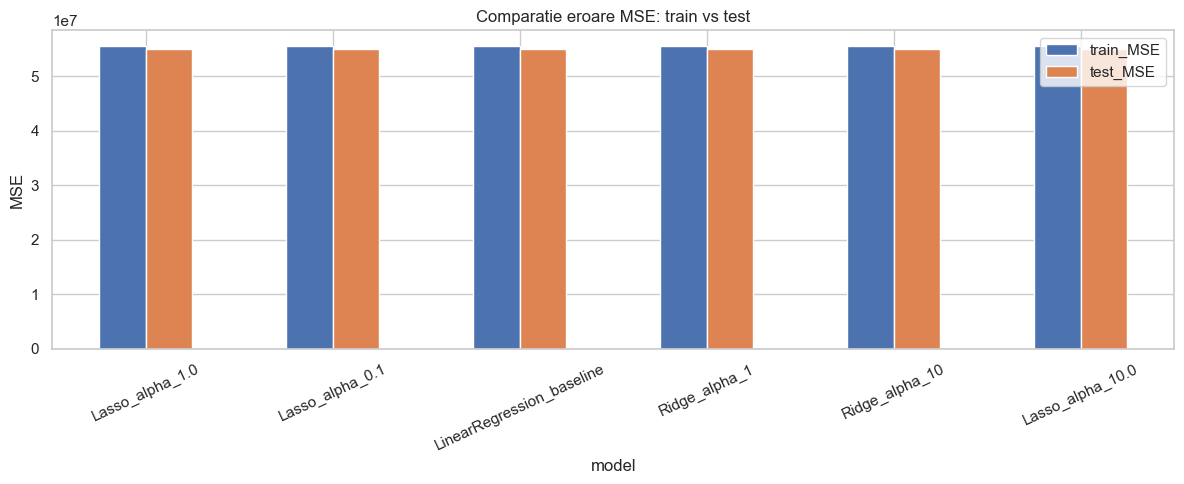

In [22]:
if PLOTS_AVAILABLE:
    plot_df = metrics_df.set_index("model")[["train_MSE", "test_MSE"]]
    ax = plot_df.plot(kind="bar", figsize=(12, 5))
    ax.set_title("Comparatie eroare MSE: train vs test")
    ax.set_ylabel("MSE")
    ax.set_xlabel("model")
    ax.tick_params(axis="x", rotation=25)
    plt.tight_layout()
    plt.show()
else:
    display(metrics_df[["model", "train_MSE", "test_MSE", "test_RMSE", "test_MAE", "test_R2"]])


## B6. Analiza erorilor pe test local

Pentru analiza calitativa alegem cel mai bun model local simplu dupa `test_MSE`. Aceasta analiza explica erorile pe setul vizibil; finalul Kaggle ramane CSV-ul din etapa data-centric.


In [23]:
best_name = metrics_df.iloc[0]["model"]
best_pred = all_predictions[best_name]
best_model = all_fitted_models[best_name]

error_df = X_test_base.copy()
error_df["salary_true"] = y_test.values
error_df["salary_pred"] = best_pred
error_df["error"] = error_df["salary_pred"] - error_df["salary_true"]
error_df["abs_error"] = error_df["error"].abs()
error_df["squared_error"] = error_df["error"] ** 2
error_df["salary_bin"] = pd.qcut(error_df["salary_true"], q=5, duplicates="drop")

print("Best local model dupa MSE:", best_name)
display(error_df.sort_values("squared_error", ascending=False).head(10))
display(error_df.groupby("salary_bin", observed=False).agg(
    count=("abs_error", "count"),
    MAE=("abs_error", "mean"),
    MSE=("squared_error", "mean"),
    max_abs_error=("abs_error", "max"),
).round(2))


Best local model dupa MSE: Lasso_alpha_1.0


,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,aggregated_score,skill_bracket,remote_work_missing,education_level_ord,company_size_ord,skill_bracket_ord,skills_per_year,experience_x_skills,certifications_per_year,salary_true,salary_pred,error,abs_error,squared_error,salary_bin
8279,Data Analyst,1,Diploma,1,Media,Small,India,Hybrid,0,-0.289082,low,0,1.0,1.0,0.0,1.000000,1,0.000000,56083,16171.873181,-39911.126819,39911.126819,1.592898e+09,"(37212.999, 113760.6]"
4656,Data Analyst,8,Diploma,5,Education,Startup,India,No,1,2.138398,low,0,1.0,0.0,0.0,0.625000,40,0.125000,65033,29932.336493,-35100.663507,35100.663507,1.232057e+09,"(37212.999, 113760.6]"
12001,AI Engineer,17,PhD,15,Retail,Enterprise,India,Hybrid,4,0.911259,high,0,4.0,4.0,2.0,0.882353,255,0.235294,158224,192554.647874,34330.647874,34330.647874,1.178593e+09,"(152483.2, 176033.6]"
12114,AI Engineer,16,PhD,13,Media,Enterprise,Canada,Yes,4,-1.328081,mid,0,4.0,4.0,1.0,0.812500,208,0.250000,294016,259794.957857,-34221.042143,34221.042143,1.171080e+09,"(176033.6, 296998.0]"
12474,Product Manager,18,PhD,14,Healthcare,Enterprise,USA,No,4,-0.876746,high,0,4.0,4.0,2.0,0.777778,252,0.222222,296998,262862.602136,-34135.397864,34135.397864,1.165225e+09,"(176033.6, 296998.0]"
13037,AI Engineer,20,PhD,6,Manufacturing,Enterprise,Canada,No,4,1.010489,low,0,4.0,4.0,0.0,0.300000,120,0.200000,293352,259680.777266,-33671.222734,33671.222734,1.133751e+09,"(176033.6, 296998.0]"
5933,Data Analyst,1,Bachelor,10,Healthcare,Small,India,Hybrid,2,-0.528163,mid,0,2.0,1.0,1.0,10.000000,10,2.000000,63141,30334.191228,-32806.808772,32806.808772,1.076287e+09,"(37212.999, 113760.6]"
13658,Data Scientist,20,PhD,15,Government,Enterprise,India,Hybrid,1,0.959366,high,0,4.0,4.0,2.0,0.750000,300,0.050000,136264,168845.748965,32581.748965,32581.748965,1.061570e+09,"(134038.4, 152483.2]"
10289,Data Scientist,0,Diploma,12,Technology,Startup,India,NaN,1,-1.089636,mid,1,1.0,0.0,1.0,12.000000,0,1.000000,74595,42050.157727,-32544.842273,32544.842273,1.059167e+09,"(37212.999, 113760.6]"
5728,Product Manager,1,High School,4,Telecom,Medium,India,NaN,2,-0.026891,low,1,0.0,2.0,0.0,4.000000,4,2.000000,92856,60629.139148,-32226.860852,32226.860852,1.038571e+09,"(37212.999, 113760.6]"


,count,MAE,MSE,max_abs_error
salary_bin,,,,
"(37212.999, 113760.6]",3200,6810.88,76361950.94,39911.13
"(113760.6, 134038.4]",3200,5633.99,51162531.00,26236.99
"(134038.4, 152483.2]",3200,5235.36,44128414.09,32581.75
"(152483.2, 176033.6]",3200,4551.88,33085457.59,34330.65
"(176033.6, 296998.0]",3200,6423.09,69936876.53,34221.04


## B7. Verificarea submission-urilor de regresie

La final verificam doua lucruri:

- `submission_regression_final.csv` exista si are formatul `id,prediction`;
- folderul `regression_csv_selected` contine doar CSV-urile reprezentative: baseline-urile simple si cate un CSV pentru fiecare etapa de perfectionare.


In [24]:
final_regression_path = Path("submission_regression_final.csv")
selected_regression_index = Path("regression_csv_selected/REGRESSION_CSV_INDEX.csv")

final_regression = pd.read_csv(final_regression_path)
assert list(final_regression.columns) == ["id", "prediction"]
assert final_regression["id"].is_unique
assert final_regression["prediction"].notna().all()

print("Regression final OK:", final_regression_path, final_regression.shape)
display(final_regression.head())

if selected_regression_index.exists():
    display(pd.read_csv(selected_regression_index))


Regression final OK: submission_regression_final.csv (16000, 2)


,id,prediction
0,1,155401.860725
1,2,136954.458255
2,3,114363.591844
3,4,118542.138268
4,5,127080.988100


,file,rows,columns,prediction_mean
0,01_baseline_minim/submission_regression_baseli...,16000,"id,prediction",156988.952350
1,01_baseline_minim/submission_regression_baseli...,16000,"id,prediction",156989.634218
2,01_baseline_minim/submission_regression_baseli...,16000,"id,prediction",156981.634677
3,02_perfectionare_kaggle/submission_regression_...,16000,"id,prediction",157346.999753
4,02_perfectionare_kaggle/submission_regression_...,16000,"id,prediction",157374.584324
5,02_perfectionare_kaggle/submission_regression_...,16000,"id,prediction",157357.458484
6,02_perfectionare_kaggle/submission_regression_...,16000,"id,prediction",157309.977688
7,02_perfectionare_kaggle/submission_regression_...,16000,"id,prediction",157310.644633
8,02_perfectionare_kaggle/submission_regression_...,16000,"id,prediction",157353.346808
9,02_perfectionare_kaggle/submission_regression_...,16000,"id,prediction",157346.999753


# PARTEA C - CLASIFICARE

Tinta de clasificare este `vacation`, cu clasele `No Vacation`, `Small`, `Medium`, `Large`.

Reperele urmarite aici:
- baseline cu `DecisionTreeClassifier`;
- variatie de hiperparametru pentru arbore;
- encodare explicita pentru atributele categorice;
- tabel cu accuracy, precision, recall si F1;
- matrice de confuzie pentru cel mai bun model;
- o etapa de perfectionare cu modele mai potrivite pentru date tabelare.

Nu folosesc `salary` in clasificare: lipseste din `CC_private_test.csv`, deci folosirea lui ar insemna leakage.


## C1. EDA specific pentru clasificare

In aceasta sectiune verificam echilibrul claselor si cateva diferente intre clase. Daca clasele sunt dezechilibrate, `accuracy` singura poate fi inselatoare, asa ca raportam si `precision`, `recall`, `F1 macro` si `F1 weighted`.


,count,percent
vacation,,
No Vacation,34686,54.20
Small,12877,20.12
Medium,8527,13.32
Large,7910,12.36


,experience_years,skills_count,certifications,total_days_worked,aggregated_score
vacation,,,,,
Large,14.651,11.862,2.563,3515.987,-0.003
Medium,12.789,11.426,2.516,3069.318,-0.012
No Vacation,7.701,11.558,2.489,1848.083,0.007
Small,11.357,11.688,2.535,2725.666,-0.004



Distributie education_level conditionata de vacation (% pe rand):


education_level,Bachelor,Diploma,High School,Master,PhD
vacation,,,,,
Large,8.67,3.88,1.98,26.71,58.75
Medium,16.89,11.23,6.22,28.84,36.82
No Vacation,22.90,27.12,30.68,13.46,5.84
Small,21.69,16.18,11.47,27.72,22.95



Distributie skill_bracket conditionata de vacation (% pe rand):


skill_bracket,high,low,mid
vacation,,,
Large,34.88,32.31,32.81
Medium,33.27,34.19,32.54
No Vacation,32.93,33.67,33.40
Small,33.07,33.56,33.38



Distributie company_size conditionata de vacation (% pe rand):


company_size,Enterprise,Large,Medium,Small,Startup
vacation,,,,,
Large,46.16,31.05,11.35,5.83,5.61
Medium,32.13,28.02,16.41,11.76,11.68
No Vacation,9.84,14.22,22.62,26.82,26.51
Small,23.41,24.52,20.47,16.14,15.46



Distributie remote_work conditionata de vacation (% pe rand):


remote_work,Hybrid,No,Yes
vacation,,,
Large,39.83,36.85,23.32
Medium,36.85,35.96,27.19
No Vacation,31.12,31.62,37.26
Small,34.53,34.38,31.09


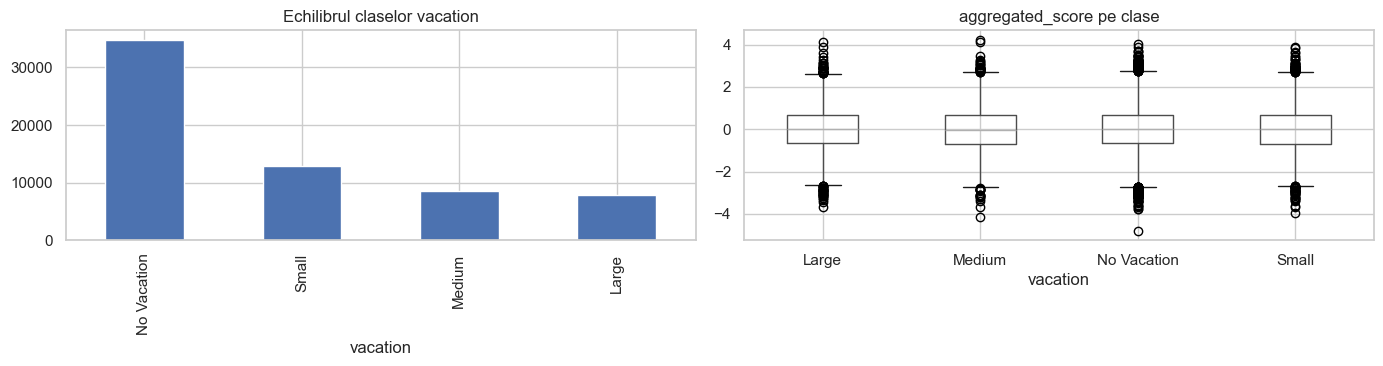

In [25]:
classification_balance = pd.concat([
    train_raw[CLASSIFICATION_TARGET].value_counts().rename("count"),
    (train_raw[CLASSIFICATION_TARGET].value_counts(normalize=True) * 100).round(2).rename("percent")
], axis=1)

display(classification_balance)

classification_numeric_cols = [
    c for c in ["experience_years", "skills_count", "certifications", "total_days_worked", "aggregated_score"]
    if c in train_raw.columns
]
classification_numeric_by_class = train_raw.groupby(CLASSIFICATION_TARGET)[classification_numeric_cols].mean().round(3)
display(classification_numeric_by_class)

for col in ["education_level", "skill_bracket", "company_size", "remote_work"]:
    if col in train_raw.columns:
        print()
        print(f"Distributie {col} conditionata de vacation (% pe rand):")
        display((pd.crosstab(train_raw[CLASSIFICATION_TARGET], train_raw[col], normalize="index") * 100).round(2))

if PLOTS_AVAILABLE:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    classification_balance["count"].plot(kind="bar", ax=axes[0], title="Echilibrul claselor vacation")
    train_raw.boxplot(column="aggregated_score", by=CLASSIFICATION_TARGET, ax=axes[1])
    axes[1].set_title("aggregated_score pe clase")
    axes[1].set_xlabel("vacation")
    fig.suptitle("")
    plt.tight_layout()
    plt.show()


## C2. Preprocesare pentru clasificare

Pentru baseline si modelele sklearn folosesc:

- doar coloane disponibile si in `CC_private_test.csv`;
- eliminare `salary`, pentru evitarea leakage-ului;
- imputare cu mediana pentru numerice;
- imputare cu `Missing` si `OneHotEncoder` pentru categorice;
- `LabelEncoder` pentru tinta `vacation`.

Etapa V1 de perfectionare adauga separat bins si interactiuni categoriale, pastrand acelasi principiu: nu folosim informatii care lipsesc din private test.


In [26]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_recall_fscore_support
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier

CLASSIFICATION_FEATURES = [
    c for c in train_raw.columns
    if c != CLASSIFICATION_TARGET and private_test_raw is not None and c in private_test_raw.columns
]
CLASSIFICATION_FEATURES = [c for c in CLASSIFICATION_FEATURES if c != REGRESSION_TARGET]

X_train_classification = train_raw[CLASSIFICATION_FEATURES].copy()
y_train_classification_raw = train_raw[CLASSIFICATION_TARGET].copy()
X_test_classification = test_raw[CLASSIFICATION_FEATURES].copy()
y_test_classification_raw = test_raw[CLASSIFICATION_TARGET].copy()

CLASSIFICATION_NUM_COLS = X_train_classification.select_dtypes(include=[np.number]).columns.tolist()
CLASSIFICATION_CAT_COLS = [c for c in X_train_classification.columns if c not in CLASSIFICATION_NUM_COLS]

classification_label_encoder = LabelEncoder()
y_train_classification = classification_label_encoder.fit_transform(y_train_classification_raw)
y_test_classification = classification_label_encoder.transform(y_test_classification_raw)

classification_preprocessor = ColumnTransformer([
    ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), CLASSIFICATION_NUM_COLS),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
        ("onehot", make_one_hot_encoder()),
    ]), CLASSIFICATION_CAT_COLS),
])

print("Features clasificare:", CLASSIFICATION_FEATURES)
print("Numerice:", CLASSIFICATION_NUM_COLS)
print("Categorice:", CLASSIFICATION_CAT_COLS)
print("Clase vacation:", list(classification_label_encoder.classes_))


Features clasificare: ['job_title', 'experience_years', 'education_level', 'skills_count', 'industry', 'company_size', 'location', 'remote_work', 'certifications', 'total_days_worked', 'aggregated_score', 'skill_bracket']
Numerice: ['experience_years', 'skills_count', 'certifications', 'total_days_worked', 'aggregated_score']
Categorice: ['job_title', 'education_level', 'industry', 'company_size', 'location', 'remote_work', 'skill_bracket']
Clase vacation: ['Large', 'Medium', 'No Vacation', 'Small']


## C3. Baseline DecisionTreeClassifier si variatie de hiperparametri

Pornesc de la un `DummyClassifier`, ca reper de underfit, apoi antrenez arbori de decizie cu valori diferite pentru `max_depth` si `min_samples_leaf`. Astfel se vede impactul hiperparametrilor asupra performantei, nu doar un singur rezultat izolat.


In [27]:
classification_results = []
classification_predictions = {}
classification_models = {}


def classification_metric_row(name, model):
    model.fit(X_train_classification, y_train_classification)
    pred = model.predict(X_test_classification)
    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        y_test_classification, pred, average="macro", zero_division=0
    )
    precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
        y_test_classification, pred, average="weighted", zero_division=0
    )
    classification_predictions[name] = pred
    classification_models[name] = model
    return {
        "model": name,
        "accuracy": accuracy_score(y_test_classification, pred),
        "precision_macro": precision_macro,
        "recall_macro": recall_macro,
        "f1_macro": f1_macro,
        "precision_weighted": precision_weighted,
        "recall_weighted": recall_weighted,
        "f1_weighted": f1_weighted,
    }

classification_results.append(classification_metric_row(
    "Dummy_most_frequent",
    DummyClassifier(strategy="most_frequent"),
))

for max_depth, min_leaf in [(4, 20), (8, 30), (None, 100)]:
    clf = Pipeline([
        ("preprocess", classification_preprocessor),
        ("model", DecisionTreeClassifier(
            max_depth=max_depth,
            min_samples_leaf=min_leaf,
            random_state=RANDOM_STATE,
            class_weight="balanced",
        )),
    ])
    classification_results.append(classification_metric_row(
        f"DecisionTree_depth{max_depth}_leaf{min_leaf}", clf
    ))

classification_baseline_df = pd.DataFrame(classification_results).sort_values("accuracy", ascending=False)
Path("classification_csv_selected").mkdir(exist_ok=True)
classification_baseline_df.to_csv("classification_csv_selected/classification_baseline_results.csv", index=False)
display(classification_baseline_df)

best_tree_name = classification_baseline_df.iloc[0]["model"]
best_tree_pred = classification_predictions[best_tree_name]
print("Cel mai bun arbore baseline:", best_tree_name)
display(pd.DataFrame(
    confusion_matrix(y_test_classification, best_tree_pred),
    index=classification_label_encoder.classes_,
    columns=classification_label_encoder.classes_,
))
print(classification_report(
    y_test_classification,
    best_tree_pred,
    target_names=classification_label_encoder.classes_,
    zero_division=0,
))

# Generam si submission-ul baseline, ca notebook-ul sa fie complet reproductibil.
if private_test_raw is not None:
    best_tree_model = classification_models[best_tree_name]
    private_tree_pred_encoded = best_tree_model.predict(private_test_raw[CLASSIFICATION_FEATURES])
    private_tree_pred = classification_label_encoder.inverse_transform(private_tree_pred_encoded)
    classification_baseline_submission = pd.DataFrame({
        "id": private_test_raw["id"],
        "prediction": private_tree_pred,
    })
    classification_baseline_submission.to_csv(
        "classification_csv_selected/submission_classification_baseline.csv",
        index=False,
    )
    display(classification_baseline_submission.head())


,model,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
3,DecisionTree_depthNone_leaf100,0.725562,0.665509,0.679052,0.668566,0.757657,0.725562,0.737356
2,DecisionTree_depth8_leaf30,0.710063,0.655355,0.669302,0.656981,0.752298,0.710063,0.724801
1,DecisionTree_depth4_leaf20,0.661438,0.602970,0.546132,0.532526,0.659416,0.661438,0.632271
0,Dummy_most_frequent,0.542000,0.135500,0.250000,0.175746,0.293764,0.542000,0.381017


Cel mai bun arbore baseline: DecisionTree_depthNone_leaf100


,Large,Medium,No Vacation,Small
Large,1456,414,55,52
Medium,391,1188,68,485
No Vacation,12,73,6975,1612
Small,49,729,451,1990


              precision    recall  f1-score   support

       Large       0.76      0.74      0.75      1977
      Medium       0.49      0.56      0.52      2132
 No Vacation       0.92      0.80      0.86      8672
       Small       0.48      0.62      0.54      3219

    accuracy                           0.73     16000
   macro avg       0.67      0.68      0.67     16000
weighted avg       0.76      0.73      0.74     16000



,id,prediction
0,1,Small
1,2,No Vacation
2,3,No Vacation
3,4,No Vacation
4,5,No Vacation


## C4. Perfectionare clasificare - V1 data-centric

Dupa baseline-ul cu arbore am comparat modele mai potrivite pentru date tabelare: RandomForest, ExtraTrees, HistGradientBoosting, LightGBM si CatBoost. Cel mai bun model simplu a fost CatBoost, ceea ce are sens aici deoarece avem multe categorice cu semnal direct pentru clasa `vacation`.

Am construit apoi o versiune V1 pentru clasificare, inspirata din lectiile de la regresie:

- bins pentru `aggregated_score`, `skills_count`, `experience_years` si `certifications`;
- indicator pentru valori extreme la `skills_count`;
- tratarea explicita a missing-ului din `remote_work`;
- interactiuni precum `job_title + location`, `job_title + experience_band`, `industry + location`;
- CatBoost cu categorice native;
- seed ensemble pe probabilitati;
- Stratified K-Fold pe train pentru verificarea stabilitatii.

Am testat trei variante: pastrare raw, eliminare `aggregated_score` raw si eliminare `certifications` raw. Cea mai buna local a fost varianta fara `aggregated_score` raw, dar cu bucket-urile si interactiunile sale pastrate.


In [28]:
classification_v1_results_path = Path("classification_csv_selected/classification_v1_kfold_results.csv")
classification_all_results_path = Path("classification_csv_selected/classification_model_results.csv")
classification_v1_confusion_path = Path("classification_csv_selected/classification_v1_confusion_matrix.csv")

classification_v1_df = pd.read_csv(classification_v1_results_path).sort_values("accuracy", ascending=False)
classification_all_models_df = pd.read_csv(classification_all_results_path).sort_values("accuracy", ascending=False)

display(classification_v1_df)
display(classification_all_models_df.head(12))

best_classification_name = classification_all_models_df.iloc[0]["model"]
print("Model final ales pentru clasificare:", best_classification_name)

if classification_v1_confusion_path.exists():
    classification_v1_confusion = pd.read_csv(classification_v1_confusion_path, index_col=0)
    display(classification_v1_confusion)

classification_v1_notes = pd.DataFrame([
    {"pas": "Feature engineering", "detaliu": "bins pentru aggregated_score/skills/experience/certifications si interactiuni job-location-experience"},
    {"pas": "Model", "detaliu": "CatBoostClassifier, categorice native, MultiClass"},
    {"pas": "K-Fold", "detaliu": "StratifiedKFold cu 3 fold-uri pentru verificarea stabilitatii pe train"},
    {"pas": "Seed ensemble", "detaliu": "3 seed-uri CatBoost, medie pe probabilitati"},
    {"pas": "Alegere finala", "detaliu": "drop aggregated_score raw; pastram bucket-urile si interactiunile"},
])
display(classification_v1_notes)


,model,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,cv_accuracy_mean,cv_f1_macro_mean,notes
0,CatBoost_V1_FE_dropagg_seed3,0.762062,0.692933,0.672087,0.681694,0.757981,0.762062,0.759469,0.759000,0.672228,"{'drop_agg': True, 'drop_cert': False}"
1,CatBoost_V1_FE_dropcert_seed3,0.761938,0.692841,0.672664,0.681963,0.758324,0.761938,0.759610,NaN,NaN,"{'drop_agg': False, 'drop_cert': True}"
2,CatBoost_V1_FE_keepraw_seed3,0.761625,0.692715,0.671522,0.681282,0.757287,0.761625,0.758882,0.759047,0.672995,"{'drop_agg': False, 'drop_cert': False}"


,model,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,cv_accuracy_mean,cv_f1_macro_mean,notes
0,CatBoost_V1_FE_dropagg_seed3,0.762062,0.692933,0.672087,0.681694,0.757981,0.762062,0.759469,0.759000,0.672228,"{'drop_agg': True, 'drop_cert': False}"
1,CatBoost_V1_FE_dropcert_seed3,0.761938,0.692841,0.672664,0.681963,0.758324,0.761938,0.759610,NaN,NaN,"{'drop_agg': False, 'drop_cert': True}"
2,CatBoost_V1_FE_keepraw_seed3,0.761625,0.692715,0.671522,0.681282,0.757287,0.761625,0.758882,0.759047,0.672995,"{'drop_agg': False, 'drop_cert': False}"
3,CatBoost_native,0.760875,0.689422,0.671664,0.679950,0.756316,0.760875,0.758166,NaN,NaN,NaN
4,HistGradientBoosting,0.760563,0.685309,0.667558,0.675647,0.752783,0.760563,0.756029,NaN,NaN,NaN
5,LightGBM_multiclass,0.760437,0.686926,0.668753,0.677159,0.753591,0.760437,0.756454,NaN,NaN,NaN
6,ExtraTrees_balanced,0.742250,0.678978,0.688981,0.681563,0.765705,0.742250,0.751317,NaN,NaN,NaN
7,RandomForest_balanced,0.741187,0.676942,0.687193,0.679817,0.763842,0.741187,0.750032,NaN,NaN,NaN
8,DecisionTree_depthNone_leaf100,0.725562,0.665509,0.679052,0.668566,0.757657,0.725562,0.737356,NaN,NaN,NaN
9,DecisionTree_depth8_leaf30,0.710063,0.655355,0.669302,0.656981,0.752298,0.710063,0.724801,NaN,NaN,NaN


Model final ales pentru clasificare: CatBoost_V1_FE_dropagg_seed3


,Large,Medium,No Vacation,Small
Large,1429,418,59,71
Medium,310,1058,102,662
No Vacation,9,35,7914,714
Small,34,453,940,1792


,pas,detaliu
0,Feature engineering,bins pentru aggregated_score/skills/experience...
1,Model,"CatBoostClassifier, categorice native, MultiClass"
2,K-Fold,StratifiedKFold cu 3 fold-uri pentru verificar...
3,Seed ensemble,"3 seed-uri CatBoost, medie pe probabilitati"
4,Alegere finala,drop aggregated_score raw; pastram bucket-uril...


## C5. Submission final si verificare pentru clasificare

Pentru predare si Kaggle pastram doua fisiere:

- `submission_classification_baseline.csv`: baseline-ul cu arbore de decizie;
- `submission_classification_final.csv`: varianta finala V1 CatBoost, aleasa dupa accuracy pe validarea locala.

Verificarea finala controleaza formatul `id,prediction`, numarul de randuri si valorile permise pentru clasa.


In [29]:
classification_final_path = Path("submission_classification_final.csv")
classification_baseline_path = Path("classification_csv_selected/submission_classification_baseline.csv")

if not classification_final_path.exists() and classification_baseline_path.exists():
    # fallback pentru rulare rapida: daca modelul de perfectionare nu a fost generat, folosim baseline-ul.
    pd.read_csv(classification_baseline_path).to_csv(classification_final_path, index=False)

classification_submission = pd.read_csv(classification_final_path)
assert list(classification_submission.columns) == ["id", "prediction"]
assert classification_submission["id"].is_unique
assert classification_submission["prediction"].isin(classification_label_encoder.classes_).all()
if private_test_raw is not None:
    assert len(classification_submission) == len(private_test_raw)
    assert set(classification_submission["id"]) == set(private_test_raw["id"])

print("Classification final OK:", classification_final_path, classification_submission.shape)
display(classification_submission.head())
display(classification_submission["prediction"].value_counts().to_frame("count"))


Classification final OK: submission_classification_final.csv (16000, 2)


,id,prediction
0,1,No Vacation
1,2,No Vacation
2,3,No Vacation
3,4,No Vacation
4,5,No Vacation


,count
prediction,
No Vacation,5349
Small,4600
Large,3060
Medium,2991
